<div style="font-family: sans-serif; margin: 15px 0;">
  <div style="font-size: 36px; font-weight: 800; color: #0c3a59; letter-spacing: 0.5px;">
    ATTACK DATASET
  </div>
  <div style="width: 80px; height: 5px; background-color: #0c3a59; border-radius: 3px; margin-top: 8px;"></div>
</div>

<div style="padding: 12px 16px; background: #f8fafc; border-left: 4px solid #0c3a59; border-radius: 4px; font-family: sans-serif; font-size: 14px; color: #334155; line-height: 1.6;">
  <b>Kelompok 1</b><br>
    <br>
  <b>Anggota:</b><br>
  1. Muhammad Afif Nuromli (5027261003)<br>
  2. Muhammad Zaid Fardhan (5027261051)<br>
  3. Yang Kui Chin (5027261069)<br>
  4. Rafky Aqeela Permana (5027261127)<br>
    <br>
  <b>Topik:</b> Cyber Security
</div>

<div style="font-size: 18px; font-weight: bold; color: #0c3a59; margin-top: 10px; margin-bottom: 8px;">Latar Belakang</div>

Serangan siber sekarang memiliki banyak macam, ada SQL Injection, XSS, CSRF, dan masih banyak lagi. Tiap serangan punya tingkat kerumitan sendiri, dilihat dari seberapa panjang deskripsinya, seberapa banyak langkahnya, dan berapa tools yang dipakai. Di dataset ini ada sekitar 14.000 catatan serangan yang bisa kita pelajari. Sebelum masuk ke analisis yang lebih kompleks, kita ingin melihat terlebih dahulu gambaran umumnya menggunakan statistik deskriptif.

---

<div style="font-size: 18px; font-weight: bold; color: #0c3a59; margin-top: 15px; margin-bottom: 8px;">Pertanyaan</div>

1. Rata-rata dan sebaran panjang deskripsi serangan (desc_len) itu seperti apa?
2. Berapa rata-rata jumlah tools yang dipakai tiap serangan (tools_count), dan apakah jumlahnya bervariasi?
3. Apakah panjang langkah serangan (steps_len) sebarannya simetris atau ada yang jauh berbeda (outlier)?

In [6]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r'C:\Users\ThinkPad\Downloads\Attack_Dataset.csv')

# Cek 5 baris pertama
df.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


In [7]:
import os
import pandas as pd
from IPython.display import HTML, display

# 1. Definisi data kamus data untuk 15 kolom
data_kamus = [
    {
        "Kolom": "ID",
        "Arti": (
            "Nomor identifikasi unik untuk setiap entri insiden keamanan siber"
        ),
        "Jenis variabel": "Kuantitatif diskrit",
        "Skala": "Rasio",
        "Satuan": "-",
        "Contoh": "1",
    },
    {
        "Kolom": "Title",
        "Arti": (
            "Nama singkat dan deskriptif dari serangan atau skenario keamanan"
            " siber"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Authentication Bypass via SQL Injection",
    },
    {
        "Kolom": "Category",
        "Arti": "Kategori atau domain utama area keamanan siber",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Mobile Security",
    },
    {
        "Kolom": "Attack Type",
        "Arti": (
            "Jenis spesifik teknik atau jenis serangan siber yang dilancarkan"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "SQL Injection (SQLi)",
    },
    {
        "Kolom": "Scenario Description",
        "Arti": (
            "Penjelasan ringkas mengenai alur kerja dan skenario terjadinya"
            " serangan"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "A login form fails to validate or sanitize input...",
    },
    {
        "Kolom": "Tools Used",
        "Arti": (
            "Perangkat lunak atau alat pengujian yang digunakan dalam serangan"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Burp Suite, SQLMap",
    },
    {
        "Kolom": "Attack Steps",
        "Arti": "Langkah-langkah sistematis pelaksanaan serangan siber",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "1. Reconnaissance: Find a login form...",
    },
    {
        "Kolom": "Target Type",
        "Arti": (
            "Jenis sistem, perangkat, atau teknologi yang menjadi sasaran"
            " serangan"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Web Login Portals",
    },
    {
        "Kolom": "Vulnerability",
        "Arti": "Kelemahan atau celah keamanan pada sistem yang dieksploitasi",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Unsanitized input fields in SQL queries",
    },
    {
        "Kolom": "MITRE Technique",
        "Arti": (
            "Kode klasifikasi teknik serangan berdasarkan standar MITRE ATT&CK"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "T1190",
    },
    {
        "Kolom": "Impact",
        "Arti": "Dampak atau risiko kerugian yang ditimbulkan akibat serangan",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Data theft, system takeover",
    },
    {
        "Kolom": "Detection Method",
        "Arti": "Metode atau teknik monitoring untuk mendeteksi adanya serangan",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Checking logs or monitoring unusual activity",
    },
    {
        "Kolom": "Solution",
        "Arti": (
            "Tindakan pencegahan atau remediation untuk mengatasi kerentanan"
        ),
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "Using secure coding or stronger encryption",
    },
    {
        "Kolom": "Tags",
        "Arti": "Kata kunci label untuk pencarian dan pengelompokan entri data",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "SQLi, WebSecurity",
    },
    {
        "Kolom": "Source",
        "Arti": "Sumber referensi atau penyedia informasi insiden siber",
        "Jenis variabel": "Kualitatif",
        "Skala": "Nominal",
        "Satuan": "-",
        "Contoh": "OWASP, MITRE ATT&CK",
    },
]

<div style="font-size: 18px; font-weight: bold; color: #0c3a59; margin-top: 10px; margin-bottom: 8px;">Sumber & Lisensi</div>

* **Sumber Data:** kaggle.com ([Link Dataset](https://www.kaggle.com/datasets/tannubarot/cybersecurity-attack-and-defence-dataset))
* **Lisensi:** MIT License ([Link Lisensi](https://www.mit.edu/~amini/LICENSE.md))
* **Ukuran Dataset:** 14.133 baris dan 16 kolom

---

<div style="font-size: 18px; font-weight: bold; color: #0c3a59; margin-top: 15px; margin-bottom: 8px;">Deskripsi Dataset</div>

Dataset ini dibuat oleh Savani Dhruv, Cario K, Tannu Barot, dan Maispace pada 25 September 2025. Dataset ini dirancang sebagai kumpulan insiden keamanan siber, ancaman, dan kerentanan yang komprehensif serta mudah dipahami untuk berbagai kalangan, mulai dari pemula hingga ahli.

In [8]:
from IPython.display import display

# Tampilkan tabel kamus langsung dari data_kamus
df_kamus = pd.DataFrame(data_kamus)
display(df_kamus)


,Kolom,Arti,Jenis variabel,Skala,Satuan,Contoh
0,ID,Nomor identifikasi unik untuk setiap entri ins...,Kuantitatif diskrit,Rasio,-,1
1,Title,Nama singkat dan deskriptif dari serangan atau...,Kualitatif,Nominal,-,Authentication Bypass via SQL Injection
2,Category,Kategori atau domain utama area keamanan siber,Kualitatif,Nominal,-,Mobile Security
3,Attack Type,Jenis spesifik teknik atau jenis serangan sibe...,Kualitatif,Nominal,-,SQL Injection (SQLi)
4,Scenario Description,Penjelasan ringkas mengenai alur kerja dan ske...,Kualitatif,Nominal,-,A login form fails to validate or sanitize inp...
5,Tools Used,Perangkat lunak atau alat pengujian yang digun...,Kualitatif,Nominal,-,"Burp Suite, SQLMap"
6,Attack Steps,Langkah-langkah sistematis pelaksanaan seranga...,Kualitatif,Nominal,-,1. Reconnaissance: Find a login form...
7,Target Type,"Jenis sistem, perangkat, atau teknologi yang m...",Kualitatif,Nominal,-,Web Login Portals
8,Vulnerability,Kelemahan atau celah keamanan pada sistem yang...,Kualitatif,Nominal,-,Unsanitized input fields in SQL queries
9,MITRE Technique,Kode klasifikasi teknik serangan berdasarkan s...,Kualitatif,Nominal,-,T1190


## A. Pemeriksaan Kualitas Data
Berikut ini adalah kumpulan kode untuk memeriksa kualitas data pada dataset:

### 1. Pemeriksaan Tipe Data

Pemeriksaan tipe data dilakukan menggunakan `df.info()` untuk mengetahui jumlah data, jumlah kolom, jumlah nilai yang tersedia, dan tipe data pada setiap kolom.

Pemeriksaan ini bertujuan untuk memastikan bahwa tipe data setiap kolom sudah sesuai dengan jenis informasinya dan tidak terdapat data yang seharusnya berupa angka tetapi terbaca sebagai teks.

In [9]:
#Tipe data setiap kolom
print("\nTipe data setiap kolom")
print(df.info())


Tipe data setiap kolom
<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack Type           14133 non-null  str  
 4   Scenario Description  14133 non-null  str  
 5   Tools Used            14119 non-null  str  
 6   Attack Steps          14133 non-null  str  
 7   Target Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
 15  Unnamed: 15           46 non-null     st

Dataset terdiri dari 14.133 baris dan 16 kolom. Kolom `ID` memiliki tipe data `int64`, sedangkan sebagian besar kolom lainnya bertipe `str` karena berisi informasi berbentuk teks.

Ditemukan kolom `Unnamed: 15` yang hampir seluruh nilainya kosong, sehingga kolom tersebut tidak memberikan informasi yang berarti untuk analisis.

### 2. Pemeriksaan Baris dan Kolom

Pemeriksaan Baris dan Kolom dilakukan untuk mengetahui jumlahnya. Fungsi `df.shape()` digunakan untuk jumlah masing-masing baris dan kolom. 

In [10]:
# Berapa baris dan kolom?
print("\nBaris, Kolom:", df.shape)


Baris, Kolom: (14133, 16)


Diketahui bahwa terdapat 14.133 baris dan 16 kolom

### 3. Pemeriksaan Nama Kolom

Pemeriksaan ini dilakukan untuk mengetahui nama dari masing masing kolom dataset

In [12]:
# Nama kolom
print("\nKolom:")
print(df.columns.tolist())


Kolom:
['ID', 'Title', 'Category', 'Attack Type', 'Scenario Description', 'Tools Used', 'Attack Steps ', 'Target Type', 'Vulnerability', 'MITRE Technique', 'Impact', 'Detection Method', 'Solution', 'Tags', 'Source', 'Unnamed: 15']


### 4. Pemeriksaan Data Duplikat

Pemeriksaan duplikat dilakukan untuk mengetahui apakah terdapat baris yang memiliki data yang sama secara keseluruhan. Fungsi `df.duplicated()` digunakan untuk mendeteksi baris duplikat, kemudian `.sum()` digunakan untuk menghitung jumlahnya.

In [13]:
# Duplikat
print("\nJumlah duplikat:", df.duplicated().sum())


Jumlah duplikat: 0


Output kode menumjukkan bahwa pada dataset ini tidak ditemukan duplikat.

### 5. Pemeriksaan Missing Values

Pemeriksaan ini berguna untuk mengetahui jumlah data yang kosong (missing values) pada setiap kolom dalam dataset. Fungsi `df.isna()` digunakan untuk mendeteksi data yang kosong, kemudian `.sum()` menghitung jumlah missing values pada masing-masing kolom.


In [14]:
# Missing values per kolom
print("Missing values:")
print(df.isna().sum())


Missing values:
ID                          0
Title                       0
Category                    0
Attack Type                 0
Scenario Description        0
Tools Used                 14
Attack Steps                0
Target Type                 4
Vulnerability              18
MITRE Technique            24
Impact                      3
Detection Method            4
Solution                    3
Tags                        3
Source                    160
Unnamed: 15             14087
dtype: int64


Berdasarkan hasil pemeriksaan, masih terdapat missing values pada beberapa kolom, yaitu `Target Type` sebanyak 4 data, `Impact` sebanyak 3 data, `Detection Method` sebanyak 4 data, `Solution` sebanyak 3 data, dan `Tags` sebanyak 3 data. Kolom lainnya tidak memiliki missing values.

### 6. Persentase Missing Values

Selain mengetahui jumlah missing values, persentasenya juga diperiksa untuk mengetahui seberapa besar proporsi data kosong dibandingkan dengan keseluruhan jumlah data.

Persentase missing values dihitung dengan membagi jumlah data kosong pada setiap kolom dengan jumlah seluruh baris, kemudian dikalikan 100.

In [15]:
# Persentase missing
print("\nPersentase missing:")
print((df.isna().sum() / len(df)) * 100)


Persentase missing:
ID                       0.000000
Title                    0.000000
Category                 0.000000
Attack Type              0.000000
Scenario Description     0.000000
Tools Used               0.099059
Attack Steps             0.000000
Target Type              0.028303
Vulnerability            0.127361
MITRE Technique          0.169815
Impact                   0.021227
Detection Method         0.028303
Solution                 0.021227
Tags                     0.021227
Source                   1.132102
Unnamed: 15             99.674521
dtype: float64


Hasil menunjukkan bahwa missing values hanya terdapat pada beberapa kolom, yaitu `Target Type` sebesar 0,0283%, `Impact` sebesar 0,0212%, `Detection Method` sebesar 0,0283%, `Solution` sebesar 0,0212%, dan `Tags` sebesar 0,0212%. Persentase missing values tersebut sangat kecil dibandingkan dengan jumlah keseluruhan data.

### 5. Keputusan dan Pembersihan Data

Berdasarkan hasil pemeriksaan, kolom `Unnamed: 15` akan dihapus karena sebagian besar nilainya kosong dan tidak memberikan informasi yang relevan.

Missing values pada kolom yang berisi informasi penting tidak dihapus karena jumlahnya sangat kecil. Untuk mempertahankan seluruh baris dataset, missing values akan diganti dengan nilai `Unknown`.

Data duplikat tidak perlu ditangani karena tidak ditemukan baris duplikat.

In [17]:
# 1. Drop kolom kosong
df = df.drop(columns=['Unnamed: 15'])

Kode ini berfungsi untuk menghapus kolom yang tidak diperlukan.

In [18]:
# 2. isi missing dengan "Unknown"
df = df.fillna('Unknown')

Kode ini berfungsi untuk mengisi seluruh missing values dengan "Unknown".

### 6. Pemeriksaan Ulang Setelah Pembersihan

Setelah proses pembersihan dilakukan, dataset diperiksa kembali untuk memastikan bahwa kolom yang tidak diperlukan telah dihapus dan tidak terdapat lagi missing values.

In [20]:
print("Missing values setelah cleaning:")
print(df.isna().sum())

print("\nUkuran dataset setelah cleaning:")
print(df.shape)

Missing values setelah cleaning:
ID                      0
Title                   0
Category                0
Attack Type             0
Scenario Description    0
Tools Used              0
Attack Steps            0
Target Type             0
Vulnerability           0
MITRE Technique         0
Impact                  0
Detection Method        0
Solution                0
Tags                    0
Source                  0
dtype: int64

Ukuran dataset setelah cleaning:
(14133, 15)


### 7. Kesimpulan Pemeriksaan Kualitas Data

Berdasarkan pemeriksaan kualitas data, dataset awal terdiri dari 14.133 baris dan 16 kolom. Ditemukan beberapa missing values pada sejumlah kolom, tetapi persentasenya sangat kecil dibandingkan dengan keseluruhan data. Selain itu, tidak ditemukan adanya data duplikat.

Kolom `Unnamed: 15` dihapus karena sebagian besar nilainya kosong dan tidak memberikan informasi yang relevan. Missing values pada kolom lainnya tidak dihapus karena jumlahnya sangat kecil dan penghapusan baris dapat mengurangi jumlah data. Sebagai gantinya, missing values diisi dengan nilai `Unknown`.

Setelah proses pembersihan, dataset memiliki 14.133 baris dan 15 kolom serta tidak memiliki missing values. Dengan demikian, dataset telah melalui tahap pembersihan dasar dan siap digunakan untuk tahap  selanjutnya.

In [30]:
df.columns = df.columns.str.strip()

# Bikin 3 kolom numerik
df['desc_len'] = df['Scenario Description'].str.len()
df['steps_len'] = df['Attack Steps'].str.len()
df['tools_count'] = df['Tools Used'].str.count(',') + 1

print("Shape:", df.shape)
df[['desc_len', 'steps_len', 'tools_count']].head()

Shape: (14133, 18)


,desc_len,steps_len,tools_count
0,117,658,3
1,219,784,4
2,220,896,4
3,245,1274,5
4,304,1162,5


## Statistik Deskriptif Numerik 

In [31]:
num_cols = ['desc_len', 'steps_len', 'tools_count']

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Modus': df[num_cols].mode().iloc[0],
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Range': df[num_cols].max() - df[num_cols].min(),
    'Varians': df[num_cols].var(),
    'Std': df[num_cols].std(),
    'Q1': df[num_cols].quantile(0.25),
    'Q3': df[num_cols].quantile(0.75),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
}).round(2)

summary

,Mean,Median,Modus,Min,Max,Range,Varians,Std,Q1,Q3,IQR
desc_len,127.57,103.0,84,30,795,765,8268.96,90.93,79.0,143.0,64.0
steps_len,698.13,554.0,399,23,6003,5980,215959.70,464.71,387.0,890.0,503.0
tools_count,2.94,3.0,3,1,22,21,1.58,1.26,2.0,3.0,1.0


### Interpretasi 
`desc_len` (panjang deskripsi):
Rata-rata panjang deskripsi adalah 127,57 karakter, sedangkan nilai tengahnya (median) 103 karakter. Karena rata-rata lebih besar dari median, berarti ada beberapa deskripsi yang jauh lebih panjang sehingga menarik rata-ratanya ke atas. Sebagian besar deskripsi berada di sekitar 79–143 karakter (Q1–Q3).

`steps_len` (panjang langkah serangan):
Rata-ratanya 698,13 karakter, sedangkan mediannya hanya 554 karakter. Perbedaan ini cukup besar, menunjukkan ada beberapa langkah serangan yang sangat panjang dibandingkan yang lainnya. Jadi, data steps_len memiliki variasi yang cukup besar (simpangan baku 464,71).

`tools_count` (jumlah tools yang digunakan):
Rata-ratanya sekitar 2,94 tools, dengan median dan modus sama-sama 3 tools. Artinya, sebagian besar serangan menggunakan sekitar 3 tools. Nilainya juga tidak terlalu menyebar (IQR = 1), sehingga jumlah tools yang digunakan cenderung lebih stabil dibandingkan dua variabel lainnya.

## Hitung varians manual

In [32]:
x = df['desc_len'].head(10)
n = len(x)
xbar = x.mean()

manual_var = ((x - xbar) ** 2).sum() / (n - 1)
manual_std = manual_var ** 0.5

print(f"Manual varians : {manual_var:.2f}")
print(f"Pandas varians : {x.var():.2f}")
print(f"Selisih        : {abs(manual_var - x.var()):.6f}")

Manual varians : 4640.22
Pandas varians : 4640.22
Selisih        : 0.000000


**Interpretasi:** Hasil perhitungan varians manual dengan rumus s² = Σ(xᵢ − x̄)² / (n − 1) menggunakan 10 baris pertama menghasilkan nilai yang sama (selisih ≈ 0) dengan hasil pandas var(). Ini membuktikan bahwa pandas menggunakan pembagi n − 1 (sampel), bukan n (populasi).

## Ringkasan Variabel Kategorik

In [33]:
# Hitung frekuensi & persentase
freq = df['Category'].value_counts()
pct = (df['Category'].value_counts(normalize=True) * 100).round(2)

# Gabung jadi tabel
tabel = pd.DataFrame({
    'Frekuensi': freq,
    'Persentase (%)': pct
})

print(f"Jumlah kategori unik: {df['Category'].nunique()}")
print(f"\nModus (paling sering): {df['Category'].mode()[0]} — {freq.max()} serangan")

print("\n=== 10 Kategori Terbanyak ===")
print(tabel.head(10))

print("\n=== 10 Kategori Paling Sedikit ===")
print(tabel.tail(10))

Jumlah kategori unik: 64

Modus (paling sering): Insider Threat — 569 serangan

=== 10 Kategori Terbanyak ===
                                             Frekuensi  Persentase (%)
Category                                                              
Insider Threat                                     569            4.03
Physical / Hardware Attacks                        548            3.88
Quantum Cryptography & Post-Quantum Threats        542            3.83
Wireless Attacks (Advanced)                        535            3.79
Malware & Threat                                   528            3.74
Satellite & Space Infrastructure Security          515            3.64
DFIR                                               510            3.61
Blockchain / Web3                                  503            3.56
Red Team                                           503            3.56
Blue Team                                          503            3.56

=== 10 Kategori Paling Sedikit ===
  

Pada kolom `Category`, terdapat **64 jenis kategori serangan**. Kategori yang paling sering muncul (modus) adalah **Insider Threat**, yaitu sebanyak **569 serangan** atau **4,03%** dari seluruh data.

Lima kategori yang paling sering muncul adalah:

Insider Threat (569)
Physical / Hardware Attacks (548)
Quantum Cryptography & Post-Quantum Threats (542)
Wireless Attacks Advanced (535)
Malware & Threat (528)
Jumlah masing-masing kategori tersebut **tidak jauh berbeda**, yaitu berkisar **3,7%–4%**.

## Histogram desc_len

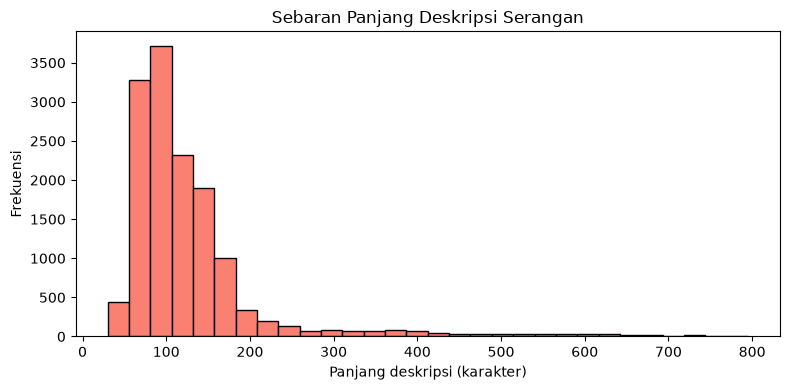

In [35]:
plt.figure(figsize=(8, 4))
plt.hist(df['desc_len'], bins=30, color='salmon', edgecolor='black')
plt.title('Sebaran Panjang Deskripsi Serangan')
plt.xlabel('Panjang deskripsi (karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `desc_len` menunjukkan sebaran yang **miring ke kanan** (right-skewed). Mayoritas deskripsi serangan panjangnya berada di kisaran **50–150 karakter**, dengan puncak frekuensi tertinggi di sekitar **80–100 karakter**.

Namun, ada **ekor panjang ke kanan** yang mencapai **795 karakter**. Ini menandakan bahwa sebagian kecil serangan memiliki deskripsi yang jauh lebih detail dan panjang dibandingkan mayoritas.

## Histogram steps_len

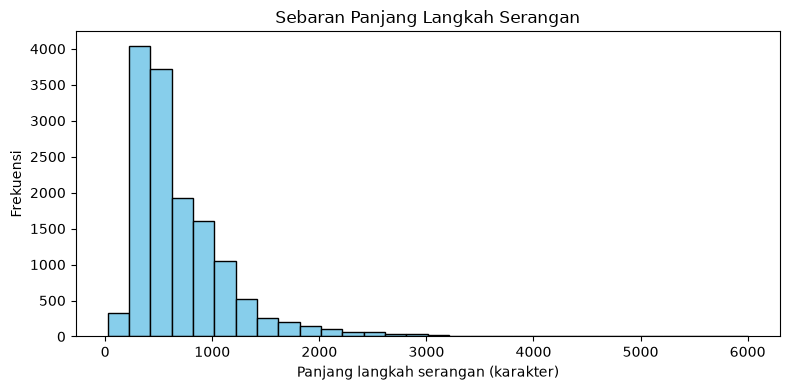

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(df['steps_len'], bins=30, color='skyblue', edgecolor='black')
plt.title('Sebaran Panjang Langkah Serangan')
plt.xlabel('Panjang langkah serangan (karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `steps_len` menunjukkan sebaran panjang langkah-langkah serangan. Sebagian besar langkah serangan memiliki panjang sekitar **200–800 karakter**.

Namun, ada beberapa serangan yang langkahnya jauh lebih panjang, bahkan mencapai **6.003 karakter**. Hal ini membuat grafik terlihat **memanjang ke arah kanan** (right-skewed).

## Histogram tools_count

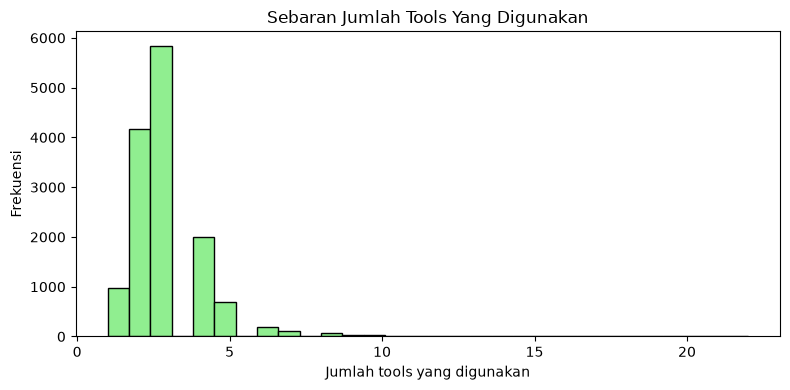

In [37]:
plt.figure(figsize=(8, 4))
plt.hist(df['tools_count'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Sebaran Jumlah Tools Yang Digunakan')
plt.xlabel('Jumlah tools yang digunakan')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `tools_count` menunjukkan sebaran jumlah tools yang digunakan. Mayoritas tiap serangan memakai **2-3 tools** yang mengisyaratkan sebagian besar attack scenario di sini adalah kasus umum dan frekuensi paling banyak dalam penggunaan tools ada di angka **3** sejumlah **5.840**. 

Histogram ini **condong ke kanan** (right-skewed), mayoritas data **menumpuk di sisi kiri** (jumlah tools kecil), lalu **ekornya memanjang tipis ke kanan** dengan sangat sedikit data di jumlah tools yang besar.

# Boxplot

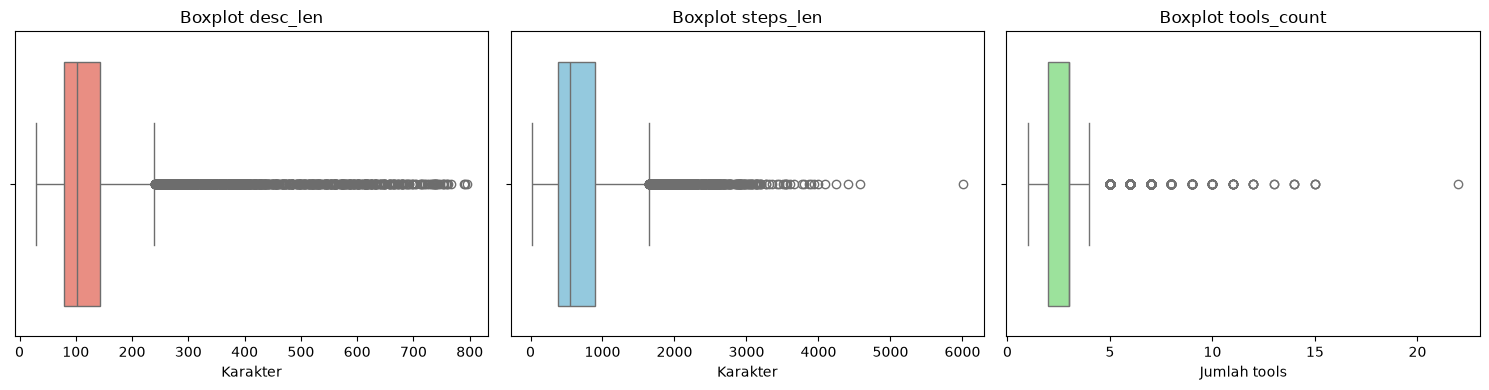

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=df['desc_len'], ax=axes[0], color='salmon')
axes[0].set_title('Boxplot desc_len')
axes[0].set_xlabel('Karakter')

sns.boxplot(x=df['steps_len'], ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot steps_len')
axes[1].set_xlabel('Karakter')

sns.boxplot(x=df['tools_count'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot tools_count')
axes[2].set_xlabel('Jumlah tools')

plt.tight_layout()
plt.show()

Ketiga boxplot menunjukkan adanya beberapa nilai yang jauh lebih tinggi dibandingkan data lainnya. Nilai seperti ini disebut **pencilan (outlier)**.

Pada `steps_len`, terdapat beberapa data dengan panjang langkah yang sangat besar, bahkan lebih dari **3.000 karakter**. Sementara itu, `tools_count` juga memiliki beberapa data yang menggunakan hingga **22 tools**. Sedangkan pada `desc_len`, outliernya tidak sejauh dua variabel lainnya.

**Kesimpulan:** Sebagian besar serangan memiliki ukuran dan jumlah tools yang normal, tetapi ada beberapa serangan yang jauh lebih panjang atau menggunakan lebih banyak tools. Hal ini menunjukkan bahwa serangan tertentu membutuhkan proses yang lebih rumit atau lebih detail dibandingkan serangan lainnya.

# Cek Outlier 1.5 x IQR

In [39]:
for k in ['desc_len', 'steps_len', 'tools_count']:
    Q1 = df[k].quantile(0.25)
    Q3 = df[k].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[k] < lower) | (df[k] > upper)]
    print(f"{k}: {len(outliers)} outlier (batas {lower:.1f} – {upper:.1f})")

desc_len: 891 outlier (batas -17.0 – 239.0)
steps_len: 652 outlier (batas -367.5 – 1644.5)
tools_count: 1136 outlier (batas 0.5 – 4.5)


### Interpretasi

Dengan menggunakan aturan **1,5 × IQR**, diperoleh jumlah pencilan (outlier) untuk masing-masing kolom numerik:

| Kolom | Jumlah Outlier | Batas Bawah | Batas Atas |
|---|---|---|---|
| `desc_len` | 891 | -17,0 | 239,0 |
| `steps_len` | 652 | -367,5 | 1.644,5 |
| `tools_count` | 1.136 | 0,5 | 4,5 |

- **`desc_len`** memiliki **891 outlier**, yaitu deskripsi yang panjangnya di atas **239 karakter**.
- **`steps_len`** memiliki **652 outlier**, yaitu langkah serangan yang panjangnya di atas **1.644,5 karakter**.
- **`tools_count`** memiliki **1.136 outlier**, yaitu serangan yang menggunakan lebih dari **4,5 tools** (artinya 5 tools ke atas).

**Kesimpulan:** Ketiga kolom memiliki pencilan di sisi kanan, yang berarti ada sebagian kecil serangan dengan tingkat kompleksitas yang jauh di atas mayoritas - baik dari sisi panjang deskripsi, panjang langkah, maupun jumlah tools yang digunakan. `tools_count` memiliki jumlah outlier terbanyak (1.136), sedangkan `steps_len` memiliki outlier dengan nilai paling ekstrem (hingga 6.003 karakter).

# Diagram Batang Kategorik

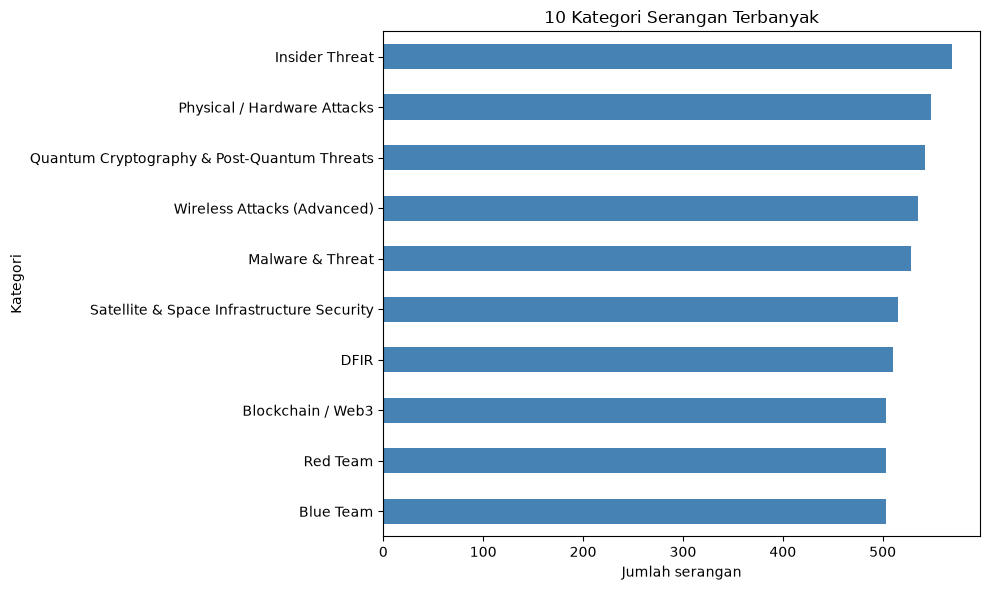

In [40]:
df['Category'].value_counts().head(10).plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('10 Kategori Serangan Terbanyak')
plt.xlabel('Jumlah serangan')
plt.ylabel('Kategori')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Diagram batang menunjukkan **10 kategori serangan yang paling sering muncul** dalam data.

Kategori **Insider Threat** memiliki jumlah paling banyak, yaitu **569 serangan**. Setelah itu ada **Physical/Hardware Attacks** sebanyak **548 serangan** dan **Quantum Cryptography** sebanyak **542 serangan**.

Jumlah 10 kategori teratas berada di sekitar **500–569 serangan**, sehingga perbedaannya tidak terlalu jauh.

**Kesimpulannya:** tidak ada satu kategori serangan yang jumlahnya jauh lebih banyak dari kategori lainnya. Data serangan **tersebar cukup merata di antara berbagai kategori**.


# Nilai Plus: Groupby Median per Kategori

Category
Blue Team                                       68.0
DFIR                                            75.0
Physical / Hardware Attacks                     77.0
Malware & Threat                                82.0
Red Team                                        82.0
Satellite & Space Infrastructure Security       84.0
Insider Threat                                  89.0
Wireless Attacks (Advanced)                     97.0
Quantum Cryptography & Post-Quantum Threats    119.0
Blockchain / Web3                              150.0
Name: desc_len, dtype: float64


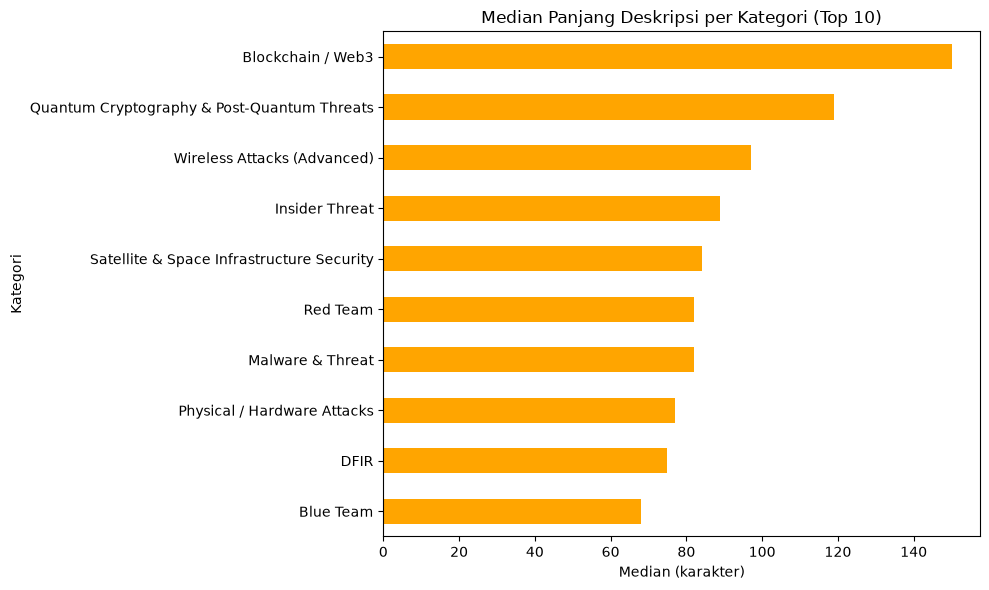

In [41]:
top_cat = df['Category'].value_counts().head(10).index
subset = df[df['Category'].isin(top_cat)]

median_per_cat = subset.groupby('Category')['desc_len'].median().sort_values()

print(median_per_cat)

median_per_cat.plot(kind='barh', color='orange', figsize=(10, 6))
plt.title('Median Panjang Deskripsi per Kategori (Top 10)')
plt.xlabel('Median (karakter)')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()



Median adalah **nilai tengah** dari data. Jadi, grafik ini menunjukkan **panjang deskripsi yang biasanya dimiliki oleh setiap kategori serangan**.

Nilai median panjang deskripsi berbeda-beda di setiap kategori. Kategori dengan median paling tinggi berarti **deskripsi serangannya biasanya lebih panjang dan lebih detail**. Sebaliknya, kategori dengan median paling rendah berarti **deskripsinya cenderung lebih singkat**.

**Kesimpulannya:** setiap kategori memiliki tingkat detail deskripsi yang berbeda-beda. Ada kategori yang biasanya dijelaskan dengan lebih panjang, dan ada juga yang cukup dijelaskan secara singkat.


# Kesimpulan

### Jawaban Pertanyaan

1. **Rata-rata panjang deskripsi serangan** adalah **127,57 karakter**. Nilai rata-ratanya lebih besar dari nilai tengahnya (median 103), sehingga sebagian data memiliki deskripsi yang jauh lebih panjang. Penyebaran datanya juga cukup beragam, dengan simpangan baku **90,93 karakter**.

2. **Rata-rata jumlah tools** yang digunakan dalam satu serangan adalah sekitar **2,94 tools**. Nilai ini hampir sama dengan mediannya, yaitu **3 tools**, sehingga jumlah tools yang digunakan cenderung **cukup stabil**, biasanya sekitar 2–3 tools.

3. **Rata-rata panjang langkah serangan** adalah **698,13 karakter**, sedangkan mediannya **554 karakter**. Perbedaan ini menunjukkan bahwa sebagian besar langkah serangan tidak terlalu panjang, tetapi ada beberapa serangan dengan langkah yang **sangat panjang**, bahkan mencapai **6.003 karakter**.

### 5 Temuan Menarik

1. **Insider Threat** merupakan kategori yang paling sering muncul, yaitu **569 serangan (4,03%)**.
2. `steps_len` memiliki variasi paling besar. Artinya, panjang langkah antarserangan bisa sangat berbeda.
3. `tools_count` merupakan data yang paling stabil. Mayoritas serangan menggunakan sekitar **2–3 tools**.
4. Terdapat banyak data yang berbeda cukup jauh dari mayoritas, yaitu **891 pada `desc_len`**, **652 pada `steps_len`**, dan **1.136 pada `tools_count`**.
5. Terdapat **64 kategori serangan**, tetapi jumlah datanya tidak sama. Hanya **10 kategori teratas** yang memiliki lebih dari 400 serangan, sedangkan kategori lainnya memiliki jumlah yang lebih sedikit.

### Keterbatasan Data

* Data ini lebih seperti **kumpulan informasi atau deskripsi tentang serangan**, bukan catatan serangan yang benar-benar terjadi di jaringan.
* Data bersifat **sintetis**, sehingga belum tentu menggambarkan kondisi serangan siber di dunia nyata.
* Beberapa informasi berupa teks yang panjang, sehingga lebih sulit untuk diubah menjadi angka dan dianalisis.
* Jumlah data pada setiap kategori berbeda-beda. Beberapa kategori memiliki banyak data, sementara kategori lainnya hanya memiliki sedikit data.

### Pertanyaan yang Bisa Diteliti Selanjutnya

Dari hasil analisis ini, kita masih bisa mencari tahu beberapa hal, misalnya:

* Apakah serangan yang menggunakan **lebih banyak tools** juga memiliki deskripsi yang lebih panjang?
* Kategori serangan mana yang memiliki **langkah-langkah paling panjang**?
* Apakah **panjang deskripsi** berhubungan dengan **panjang langkah serangan**?
* Apakah semakin banyak tools yang digunakan berarti langkah serangannya juga semakin panjang?

**Secara sederhana, dataset ini menunjukkan bahwa setiap serangan memiliki tingkat detail yang berbeda-beda. Kebanyakan serangan berada pada ukuran yang relatif normal, tetapi ada beberapa serangan yang jauh lebih panjang dan menggunakan lebih banyak tools.**


# Referensi & Catatan Penggunaan AI


## Tabel Penggunaan AI

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| ChatGPT | Menanyakan arti error `KeyError: 'pm 25'` | Nama kolom harus sama persis, termasuk spasi. Solusinya: `df.columns.str.strip()` |
| ChatGPT | Menanyakan beda **varians** dan **simpangan baku** | Varians = rata-rata kuadrat deviasi; simpangan baku = akar dari varians |
| ChatGPT | Menanyakan fungsi `df.info()` vs `df.describe()` | `df.info()` untuk tipe data & missing; `df.describe()` untuk statistik deskriptif numerik |
| ChatGPT | Menanyakan cara cek missing values dan persentasenya | `df.isna().sum()` untuk jumlah; `(df.isna().sum() / len(df)) * 100` untuk persentase |
| ChatGPT | Menanyakan cara hapus kolom yang tidak dipakai | `df.drop(columns=['Unnamed: 15'])` |
| ChatGPT | Menanyakan cara isi missing value dengan string | `df.fillna('Unknown')` |
| ChatGPT | Menanyakan fungsi `str.split(',').explode().str.strip()` | Memecah kolom teks berisi daftar (dipisah koma) menjadi baris terpisah, lalu dibersihkan spasinya |
| ChatGPT | Menanyakan regex `r'T\d{4}(?:\.\d{3})?'` | `T` + 4 digit, opsional `.` + 3 digit, untuk mengekstrak kode MITRE ATT&CK |
| ChatGPT | Menanyakan cara membuat kolom panjang teks | `df['Scenario Description'].str.len()` untuk panjang karakter |
| ChatGPT | Menanyakan cara membuat kolom jumlah tools | `df['Tools Used'].str.count(',') + 1`jumlah tools = jumlah koma + 1 |
| ChatGPT | Menanyakan cara cek outlier dengan aturan **1.5 × IQR** | `Q1 - 1.5*IQR` (batas bawah) dan `Q3 + 1.5*IQR` (batas atas); nilai di luar batas = outlier |
| ChatGPT | Menanyakan parameter `figsize`, `bins`, `edgecolor` di Matplotlib | `figsize` ukuran gambar; `bins` jumlah bin histogram; `edgecolor` warna garis tepi batang |
| ChatGPT | Menanyakan cara `groupby().median()` per kategori | `subset.groupby('Category')['desc_len'].median().sort_values()` untuk median per grup |
| ChatGPT | Menanyakan cara `invert_yaxis()` di barh | Membalik urutan sumbu Y agar kategori terbesar muncul di atas |
| ChatGPT | Menanyakan arti `pd.DataFrame(data_kamus)` dari list of dict | Membuat tabel kamus data dari struktur list berisi dict |
| ChatGPT | Menanyakan cara menampilkan tabel rapi di Jupyter | `from IPython.display import display; display(df_kamus)` |
| ChatGPT | Menanyakan cara `%matplotlib inline` dan `sns.set_style()` | `%matplotlib inline` agar grafik tampil di notebook; `set_style("whitegrid")` untuk tema grid putih |

---

## Referensi Penulisan Kode

### 1. `df.columns.str.strip()` - Membersihkan spasi pada nama kolom

**file** (`tugas4(Afif).ipynb` - bagian *data load*):

```python
df.columns = df.columns.str.strip()
```

**Referensi:**
- [Pandas: Index.str.strip](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html) - dokumentasi resmi `.str.strip()` pada index/kolom.

---

### 2. `str.split(',').explode().str.strip()` - ngesplit 

**file** (`tugas2(fardhan).ipynb`):

```python
tools = df['Tools Used'].dropna().str.split(',').explode().str.strip()
```

**Referensi:**
- [Kanaries: Pandas String Operations](https://docs.kanaries.net/topics/Pandas/pandas-string-operations) - contoh `.str.split().explode().str.strip()`.

---

### 3. `Q1 = df.quantile(0.25)` dan `IQR = Q3 - Q1` - Deteksi outlier

**file** (`tugas4(Afif).ipynb` - bagian *Cek Outlier 1.5 x IQR*):

```python
Q1 = df[k].quantile(0.25)
Q3 = df[k].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[k] < lower) | (df[k] > upper)]
```

**Referensi:**
- [Stack Overflow: Remove Outliers in Pandas DataFrame using Percentiles](https://stackoverflow.com/questions/35827863/remove-outliers-in-pandas-dataframe-using-percentiles) - kode `Q1 = df.quantile(0.25)` dll.

---

### 4. `df['Category'].value_counts().head(10).plot(kind='barh')` - Diagram batang horizontal

**file** (`tugas4(Afif).ipynb` - bagian *Diagram Batang Kategorik*):

```python
df['Category'].value_counts().head(10).plot(kind='barh', color='steelblue', figsize=(10, 6))
```

**Referensi:**
- [Stack Overflow: How to plot bars from pandas value_counts](https://stackoverflow.com/questions/36762199/how-to-plot-bars-from-pandas-value-counts) - contoh `value_counts().plot(kind='barh')`.
- [Stack Overflow: Revisions 7b9e2c6f](https://stackoverflow.com/revisions/7b9e2c6f-cdf7-472a-93ad-2879f77790db/view-source) - memuat `.head(10).plot`.

---


### 5. `subset.groupby('Category')['desc_len'].median()` - Median per grup

**file** (`tugas4(Afif).ipynb` - bagian *Groupby Median per Kategori*):

```python
median_per_cat = subset.groupby('Category')['desc_len'].median().sort_values()
```

**Referensi:**
- [Pandas: GroupBy.median](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.GroupBy.median.html) - dokumentasi resmi.

---

### 6. `df['Tools Used'].str.count(',') + 1` - Menghitung jumlah tools

**file** (`tugas4(Afif).ipynb` - bagian *data load*):

```python
df['tools_count'] = df['Tools Used'].str.count(',') + 1
```

**Referensi:**
- [Stack Overflow: Count separators in CSV rows with Pandas](https://stackoverflow.com/questions/53862765/count-separators-in-csv-rows-with-pandas) - pola `.str.count(',') + 1`.

---

### 7. `(df.isna().sum() / len(df)) * 100` - Persentase missing values

**file** (`tugas2(fardhan).ipynb` - bagian *Persentase Missing Values*):

```python
print((df.isna().sum() / len(df)) * 100)
```

**Referensi:**
- [Stack Overflow: Revision 4db32e01](https://stackoverflow.com/revisions/4db32e01-c36c-41b3-b5e2-1bf2a9f2539e/view-source) - rumus yang sama.

---

### 8. `fig, axes = plt.subplots(1, 3, figsize=(15, 4))` + `sns.boxplot` - Boxplot banyak kolom

**file** (`tugas4(Afif).ipynb` - bagian *Boxplot 3 Kolom*):

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=df['desc_len'], ax=axes[0], color='salmon')
```

**Referensi:**
- [Arab Psychology: Adjust Figure Size of Seaborn Plot](https://scales.arabpsychology.com/stats/how-can-the-figure-size-of-a-seaborn-plot-be-adjusted/) - contoh `plt.subplots` + `sns.boxplot`.

---

### 9. `df.fillna('Unknown')` - Mengisi missing value

**file** (`tugas2(fardhan).ipynb` - bagian *Pembersihan Data*):

```python
df = df.fillna('Unknown')
```

**Referensi:**
- [Pandas: DataFrame.fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) - dokumentasi resmi.

---

### 10. `df.duplicated().sum()` - Memeriksa baris duplikat

**file** (`tugas2(fardhan).ipynb` - bagian *Pemeriksaan Data Duplikat*):

```python
print("Jumlah duplikat:", df.duplicated().sum())
```

**Referensi:**
- [Pandas: DataFrame.duplicated](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html) - dokumentasi resmi.
- [GeeksforGeeks: Pandas duplicated](https://www.geeksforgeeks.org/python-pandas-dataframe-duplicated/) - penjelasan & contoh.

---

### 11. `df.drop(columns=['Unnamed: 15'])` - Menghapus kolom

**file** (`tugas2(fardhan).ipynb` - bagian *Pembersihan Data*):

```python
df = df.drop(columns=['Unnamed: 15'])
```

**Referensi:**
- [Pandas: DataFrame.drop](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) - dokumentasi resmi.

---

### 12. `df.info()` - Melihat tipe data dan missing

**file** (`tugas2(fardhan).ipynb` - bagian *Pemeriksaan Tipe Data*):

```python
print(df.info())
```

**Referensi:**
- [Pandas: DataFrame.info](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) - dokumentasi resmi.
- [W3Schools: Pandas DataFrame info()](https://www.w3schools.com/python/pandas/ref_df_info.asp) - penjelasan.

---

### 13. `display(df_kamus)` - Menampilkan tabel di Jupyter

**file** (`tugas1(rafky).ipynb` - bagian *Kamus Data*):

```python
from IPython.display import display
display(df_kamus)
```

**Referensi:**
- [IPython: display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html) - dokumentasi resmi.

---


## Referensi Sumber Dataset

- **Dataset:** [Kaggle - Cybersecurity Attack and Defence Dataset](https://www.kaggle.com/datasets/tannubarot/cybersecurity-attack-and-defence-dataset)
- **Lisensi:** MIT License

## Referensi Workflow EDA

- **Data Science for Beginners (GitHub)** - https://github.com/Srdiegoibs/Data-Science-For-Beginners

---